# Chess Rating Systems: Building and Comparing Elo & Glicko-2

**Author:** Atilla Ahmed.
**Data Sources:** Lichess Game Database (Kaggle) · FIDE Official Rating Lists

## Table of Content

1. Introduction
2. Data Loading & Initial Inspection
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis
5. Mathematical Framework
6. Implementation
7. Hypothesis Testing
8. Conclusion
9. Self-Assessment

---

## 1. Introduction

### 1.1 Motivation

I play chess online and I've always been curious about what the rating number actually means mathematically. The **Elo system**, introduced in the 1960s by Arpad Elo and adopted by FIDE in 1970, uses a logistic function to estimate the probability that one player beats another based on their rating difference. It's simple and widely used, but it has a weakness it doesn't track how *certain* the system is about a player's rating.

**Glicko-2** (Glickman, 2001) solves this by adding a rating deviation (uncertainty) and a volatility parameter per player. Lichess uses Glicko-2; FIDE still uses Elo. In this project I derive both systems from scratch, implement them in Python, and test them on real data.

### 1.2 Problem Statement & Objectives

> **How well do Elo and Glicko-2 predict chess outcomes, and what do online (Lichess) and over-the-board (FIDE) data reveal about how ratings behave in practice?**

Specific questions I want to answer:

1. How well-calibrated is the Elo prediction? (If the model says 70% win chance, does white win ~70% of the time?)
2. Is white's first-move advantage statistically significant, and does it vary by rating level?
3. Do certain openings produce significantly different win rates?
4. How do Lichess and FIDE rating distributions compare structurally?
5. Is there a gender gap in FIDE ratings, and can participation rates explain it?
6. Can a logistic regression model that includes color, opening, and time control outperform pure Elo?

Each of these is formalized as a hypothesis test or model comparison in Sections 6–7.

The project has three goals: derive the math behind Elo and Glicko-2 with full formulas, implement both from scratch (no pre-built rating libraries), and run statistical analysis on real data from two independent sources.

### 1.3 Data Sources

**Lichess (Kaggle)** - 20,000+ online games in CSV format. Each row is a game with both players' ratings, the result, opening name/ECO code, number of moves, and time control. Licensed CC0.

**FIDE (ratings.fide.com)** - official rating list in fixed-width TXT. Each row is a player with Standard/Rapid/Blitz ratings, title, federation, gender, and birth year.

The two datasets can't be merged at the player level (no shared ID), but I compare them at the aggregate level, distribution shapes, population parameters, and how the Elo formula performs in each context.

### 1.4 Prior Work

Elo described his system in *The Rating of Chessplayers, Past and Present* (1978). Glickman published Glicko-2 in 2001 — his paper *"Example of the Glicko-2 System"* is the main reference I follow for the implementation. There's also ML-based approaches (logistic regression, gradient boosting) that can outperform Elo in raw accuracy, but I'm more interested in understanding the mathematical structure than maximizing a metric.

## 2. Data Loading and Initial Inspection
This section Loads both datasets, check their structure, and flags anything that need attention before the real analysis. The Lichess data comes as a standard CSV with one row per game. The FIDE data is a fixed-width text file a snapshot of every registered player with their current ratings.

### 2.0 Setup and Imports

In [30]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, binomtest

### 2.1 Loading the Lichess Dataset
The Lichess data is a CSV from Kaggle containing ~20,000 games played.


In [31]:
lichess = pd.read_csv('games.csv')
# Let's look the shape
print(f'Shape: {lichess.shape[0]:,} rows x {lichess.shape[1]:,} columns ')
print()

# Columns types and non-null counts
lichess.info()

Shape: 20,058 rows x 16 columns 

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage

In [32]:
# Preview first 5 rows
lichess.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [33]:
# Statistics for Numerical Columns
lichess.describe().T

,count,mean,std,min,25%,50%,75%,max
created_at,20058.0,1.483617e+12,2.850151e+10,1.376772e+12,1.477548e+12,1.496010e+12,1.503170e+12,1.504493e+12
last_move_at,20058.0,1.483618e+12,2.850140e+10,1.376772e+12,1.477548e+12,1.496010e+12,1.503170e+12,1.504494e+12
turns,20058.0,6.046600e+01,3.357058e+01,1.000000e+00,3.700000e+01,5.500000e+01,7.900000e+01,3.490000e+02
white_rating,20058.0,1.596632e+03,2.912534e+02,7.840000e+02,1.398000e+03,1.567000e+03,1.793000e+03,2.700000e+03
black_rating,20058.0,1.588832e+03,2.910361e+02,7.890000e+02,1.391000e+03,1.562000e+03,1.784000e+03,2.723000e+03
opening_ply,20058.0,4.816981e+00,2.797152e+00,1.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,2.800000e+01


Check for missing values the '.info()' above showed all columns as non-null, but i will check to confirm is everything is okay.

In [34]:
missing_lichess = lichess.isnull().sum()
missing_pct = (missing_lichess / len(lichess)) * 100 # as percentage of total

# Now display columns with missing values (if any)
missing_df = pd.DataFrame({
    'Missing': missing_lichess,
    'Percentage': missing_pct
})
missing_df[missing_df['Missing'] > 0] # Filtering to show only problematic columns
# If this table is empty - no missing data at all

,Missing,Percentage


Unique values for key categorical columns, this tells me how many distinct players, openings, and result types exists:

In [35]:
cat_cols = ['winner', 'victory_status', 'increment_code', 'opening_eco', 'opening_name']
for col in cat_cols:
    n_unique = lichess[col].nunique() # count distinct values
    top_val = lichess[col].value_counts().index[0] # most frequent value
    top_pct = lichess[col].value_counts(normalize=True).iloc[0] * 100
    print(f'{col:20s} → {n_unique:>5,} unique | most common: "{top_val}" ({top_pct:.1f}%)')

winner               →     3 unique | most common: "white" (49.9%)
victory_status       →     4 unique | most common: "resign" (55.6%)
increment_code       →   400 unique | most common: "10+0" (38.5%)
opening_eco          →   365 unique | most common: "A00" (5.0%)
opening_name         → 1,477 unique | most common: "Van't Kruijs Opening" (1.8%)


### 2.2 Loading the FIDE Dataset
The FIDE data is a rating list snapshot from ratings.fide.com with ~1.8 million registered players. Each row is one player with their Standard, Rapid, and Blitz Elo ratings, plus metadata like title, federation, gender, and birth year. The column names use FIDE's standard abbreviations — I'll rename them for clarity.

In [36]:
fide = pd.read_fwf('players_list_foa.txt')
print(f'Shape: {fide.shape[0]:,} rows x {fide.shape[1]:,} columns ')
print()

print('Columns:', list(fide.columns))
print()

print(fide.dtypes)


Shape: 1,816,699 rows x 19 columns 

Columns: ['ID Number', 'Name', 'Fed', 'Sex', 'Tit', 'WTit', 'OTit', 'FOA', 'SRtng', 'SGm', 'SK', 'RRtng', 'RGm', 'Rk', 'BRtng', 'BGm', 'BK', 'B-day', 'Flag']

ID Number    int64
Name           str
Fed            str
Sex            str
Tit            str
WTit           str
OTit           str
FOA            str
SRtng        int64
SGm          int64
SK           int64
RRtng        int64
RGm          int64
Rk           int64
BRtng        int64
BGm          int64
BK           int64
B-day        int64
Flag           str
dtype: object


FIDE uses cryptic column abbreviations. Here's what each one means, i'll rename some of them later for readability:

| Column | Meaning |
|--------|---------|
| `SRtng` / `SGm` / `SK` | Standard rating, games, K-factor |
| `RRtng` / `RGm` / `Rk` | Rapid rating, games, K-factor |
| `BRtng` / `BGm` / `BK` | Blitz rating, games, K-factor |
| `Tit` | FIDE title (GM, IM, FM, CM, WGM, ...) |
| `WTit` | Women's title |
| `Fed` | Federation (country code, e.g. BUL, USA, RUS) |
| `B-day` | Birth year |
| `Flag` | Activity flag (i = inactive, w = woman-inactive, etc.) |

In [37]:
# First 5 rows:
fide.head()

,ID Number,Name,Fed,Sex,Tit,WTit,OTit,FOA,SRtng,SGm,SK,RRtng,RGm,Rk,BRtng,BGm,BK,B-day,Flag
0,564033791,564033783,IND,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2017,NaN
1,40129322,9147028,NED,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1530,0,20,1995,NaN
2,10292519,"A A M Imtiaz, Chowdhury",BAN,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1975,NaN
3,10688862,"A Abdel Maabod, Hoda",EGY,F,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2009,w
4,577017641,A Adhisiva,IND,M,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,2015,NaN


In [38]:
# Descriptive Statistics
fide.describe().T

,count,mean,std,min,25%,50%,75%,max
ID Number,1816699.0,1.105937e+08,1.948319e+08,100013.0,6559127.0,24132403.0,54196802.0,706088288.0
SRtng,1816699.0,5.198892e+02,8.073976e+02,0.0,0.0,0.0,1510.0,2840.0
SGm,1816699.0,1.649266e-01,1.030813e+00,0.0,0.0,0.0,0.0,36.0
SK,1816699.0,9.367054e+00,1.539785e+01,0.0,0.0,0.0,20.0,40.0
RRtng,1816699.0,4.050264e+02,7.268124e+02,0.0,0.0,0.0,0.0,2832.0
RGm,1816699.0,1.305549e-01,1.194110e+00,0.0,0.0,0.0,0.0,311.0
Rk,1816699.0,7.141272e+00,1.362389e+01,0.0,0.0,0.0,0.0,40.0
BRtng,1816699.0,2.782552e+02,6.412555e+02,0.0,0.0,0.0,0.0,2869.0
BGm,1816699.0,9.610563e-02,1.188960e+00,0.0,0.0,0.0,0.0,261.0
BK,1816699.0,4.077000e+00,9.989860e+00,0.0,0.0,0.0,0.0,40.0


Missing values in FIDE data, many players don't have Rapid or Blitz ratings, and titles are only held by a small fraction of registered players:

In [39]:
# Missing values per column
missing_fide = fide.isnull().sum()                     # count NaN per column
missing_fide_pct = (missing_fide / len(fide) * 100)    # as percentage

missing_fide_df = pd.DataFrame({
    'Missing': missing_fide,
    'Percent': missing_fide_pct
}).sort_values('Percent', ascending=False)              # sort by severity

missing_fide_df[missing_fide_df['Missing'] > 0]        # show only columns with gaps

,Missing,Percent
WTit,1811671,99.723234
OTit,1811165,99.695382
FOA,1801280,99.151263
Tit,1792550,98.670721
Flag,1244083,68.480414


In [40]:
#  Check for "unrated" players (rating = 0 means no official rating)
for col in ['SRtng', 'RRtng', 'BRtng']:                # the three rating columns
    n_zero = (fide[col] == 0).sum()                      # count players with rating = 0
    pct_zero = n_zero / len(fide) * 100                  # as percentage
    print(f'{col}: {n_zero:>9,} zeros ({pct_zero:.1f}%)')

SRtng: 1,275,497 zeros (70.2%)
RRtng: 1,379,776 zeros (75.9%)
BRtng: 1,524,341 zeros (83.9%)


### 2.3 First Impressions

**Lichess:** 20,058 games, zero missing values across all 16 columns. Ratings range from 784 to 2723 (mean ~1,597 for white, ~1,589 for black), which covers everything from absolute beginners to strong masters. The average game lasts about 60 moves, with a maximum of 349 some real marathon games in there. White wins 49.9% of the time, resign is the most common result (55.6%), and there are 1,477 distinct opening names. No cleaning needed for this dataset.

**FIDE:** 1.8 million registered players, but the majority are "ghost entries" players registered with a federation who have never earned an official rating. Standard rating is zero for 70.2% of players, Rapid for 75.9%, and Blitz for 83.9%. After filtering out the zeros, I'll be working with roughly 541K players for Standard, 437K for Rapid, and 292K for Blitz still very large samples. Title columns are mostly empty (98.7% for `Tit`) because only a tiny fraction of chess players ever earn a FIDE title. The `Flag` column is NaN for 68.5% of entries, which likely means "active" the flag values mark inactive or special-status players.

Both datasets loaded successfully. The Lichess data is ready to use as-is. The FIDE data needs filtering (remove zero-rated entries) and some column renaming for readability before I can do anything meaningful with it.

## 3. Data Cleaning & Preprocessing
The Lichess dataset came in surprisingly clean: no missing values, sensible dtypes, and nothing that looks like a data entry error. The FIDE data is a different story. Most of the 1.8 million rows are 'ghost entries' - players registered with a federation who never got an official rating. I need to filter those out, handle the 'Flag' column, and do some renaming so the column names actually make sense to someone reading this.

### 3.1 Lichess Validation & feature engineering
There's nothing to clean here, but I do want to verify the zero-missing claim from Section 2

In [41]:
# Verify no missing values
print('Missing values per column:')
print(lichess.isnull().sum())
print(f'\nDuplicate rows: {lichess.duplicated().sum()}')

Missing values per column:
id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

Duplicate rows: 429


In [42]:
# Drop duplicates by game ID only
# Same ID = same game exported twice/thrice. Different ID = different game.
print(f'Before: {len(lichess):,} rows')
lichess = lichess.drop_duplicates(subset='id', keep='first')  # keep first occurrence of each game ID
lichess = lichess.reset_index(drop=True)                       # clean index
print(f'After:  {len(lichess):,} rows')
print(f'Dropped: {20058 - len(lichess):,} duplicate game entries')

Before: 20,058 rows
After:  19,113 rows
Dropped: 945 duplicate game entries


945 rows dropped - all cases where the same game ID appeared more than once. The remaining 19,113 rows are unique games. Now I'll create derived columns I need for the Elo analysis.

In [43]:
#Rating difference: white minus black
#This is the main predictor for the Elo expected score formula.
#Positive = white is stronger, negative = black is stronger.
lichess['rating_diff'] = lichess['white_rating'] - lichess['black_rating']
print(f'rating_diff range: [{lichess["rating_diff"].min()}, {lichess["rating_diff"].max()}]')
print(f'Mean: {lichess["rating_diff"].mean():.1f}')
print(f'Median: {lichess["rating_diff"].median():.0f}')

rating_diff range: [-1605, 1499]
Mean: 7.3
Median: 3


In [44]:
# Numeric outcome from white's perspective
# Elo needs a numeric score: 1 for win, 0.5 for draw, 0 for loss.
# The 'winner' column has values: 'white', 'black', 'draw'.
outcome_map = {'white': 1.0, 'draw': 0.5, 'black': 0.0}  # map strings to floats
lichess['white_score'] = lichess['winner'].map(outcome_map)  # apply the mapping

# Verify no unmapped values crept in
print(f'Any NaN in white_score: {lichess["white_score"].isna().sum()}')
print(f'\nwhite_score distribution:')
print(lichess['white_score'].value_counts().sort_index())

Any NaN in white_score: 0

white_score distribution:
white_score
0.0    8680
0.5     888
1.0    9545
Name: count, dtype: int64


In [45]:
# Average rating of both players
# Useful for grouping games by skill level later.
lichess['avg_rating'] = (lichess['white_rating'] + lichess['black_rating']) / 2

# Rating band (every 200 points)
# Bins like 800-1000, 1000-1200, etc. for grouped analysis.
lichess['rating_band'] = (lichess['avg_rating'] // 200 * 200).astype(int)

print('Rating band distribution:')
print(lichess['rating_band'].value_counts().sort_index())

Rating band distribution:
rating_band
800       87
1000    1023
1200    3423
1400    5845
1600    4467
1800    2848
2000    1165
2200     244
2400      11
Name: count, dtype: int64


### 3.2 FIDE - Filtering Ghost Entries

In [46]:
# How many players have at least one non-zero rating?
has_standard = fide['SRtng'] > 0
has_rapid = fide['RRtng'] > 0
has_blitz = fide['BRtng'] > 0
has_any = has_standard | has_rapid | has_blitz # at least one format rated

print(f'Players with Standard rating: {has_standard.sum():,}')
print(f'Players with Rapid rating:    {has_rapid.sum():,}')
print(f'Players with Blitz rating:    {has_blitz.sum():,}')
print(f'Players with ANY rating:      {has_any.sum():,}')
print(f'Ghost entries (all zeros):    {(~has_any).sum():,}')

Players with Standard rating: 541,202
Players with Rapid rating:    436,923
Players with Blitz rating:    292,358
Players with ANY rating:      740,720
Ghost entries (all zeros):    1,075,979


In [47]:
# Keep only players who have at least one official rating
fide_rated = fide[has_any].copy()
print(f'FIDE rated players: {len(fide_rated):,} (was {len(fide):,})')
print(f'Dropped: {len(fide) - len(fide_rated):,} ghost entries')

FIDE rated players: 740,720 (was 1,816,699)
Dropped: 1,075,979 ghost entries


### 3.3 FIDE - Column Renaming & Cleanup
The original column names ('SRtng', 'SGm', 'SK') are compact but a little bit hard for the readers. I'll rename them so the notebook reads more naturally, and clean up the 'Flag', 'Sex', 'Title' columns.

In [48]:
# Rename columns for readability
rename_map = {
    'SRtng': 'std_rating',     # Standard rating
    'SGm':   'std_games',      # Standard games played
    'SK':    'std_k',          # Standard K-factor
    'RRtng': 'rapid_rating',   # Rapid rating
    'RGm':   'rapid_games',    # Rapid games played
    'Rk':    'rapid_k',        # Rapid K-factor
    'BRtng': 'blitz_rating',   # Blitz rating
    'BGm':   'blitz_games',    # Blitz games played
    'BK':    'blitz_k',        # Blitz K-factor
    'Tit':   'title',          # FIDE title (GM, IM, FM, etc.)
    'WTit':  'w_title',        # Women's title
    'Fed':   'federation',     # Country/federation code
    'B-day': 'birth_year',     # Year of birth
    'Flag':  'flag',           # Activity flag
    'Sex':   'sex',            # M or F
}
fide_rated = fide_rated.rename(columns=rename_map)
print('Renamed columns')
print(fide_rated.columns.tolist())

Renamed columns
['ID Number', 'Name', 'federation', 'sex', 'title', 'w_title', 'OTit', 'FOA', 'std_rating', 'std_games', 'std_k', 'rapid_rating', 'rapid_games', 'rapid_k', 'blitz_rating', 'blitz_games', 'blitz_k', 'birth_year', 'flag']


In [49]:
# Flag column: Nan means 'active'
# Players with no flag are presumably active.
# Actual flag values mark inactive/special status.
print('Flag values before cleaning:')
print(fide_rated['flag'].value_counts(dropna=False))

fide_rated['is_active'] = fide_rated['flag'].isna()   # True if no flag = active
print(f'\nActive players: {fide_rated["is_active"].sum():,}')
print(f'Flagged (inactive/other): {(~fide_rated["is_active"]).sum():,}')

Flag values before cleaning:
flag
NaN    375730
i      288665
w       39134
wi      37191
Name: count, dtype: int64

Active players: 375,730
Flagged (inactive/other): 364,990


In [50]:
#Sex column: check distribution
print('Sex distribution (rated players):')
print(fide_rated['sex'].value_counts(dropna=False))
print(f'\nFemale percentage: {(fide_rated["sex"] == "F").mean() * 100:.1f}%')

Sex distribution (rated players):
sex
M    664395
F     76325
Name: count, dtype: int64

Female percentage: 10.3%


In [51]:
# Title column: fill NaN with 'Untitled' for easier grouping
fide_rated['title'] = fide_rated['title'].fillna('Untitled')  # explicit label instead of NaN

print('Title distribution (rated players):')
print(fide_rated['title'].value_counts().head(10))

Title distribution (rated players):
title
Untitled    716645
FM            9595
IM            4259
CM            3616
WFM           2160
GM            1878
WCM           1303
WIM            925
WGM            339
Name: count, dtype: int64


In [52]:
# Birth year: check for unreasonable values
print('Birth year stats:')
print(fide_rated['birth_year'].describe())

# Players with birth_year = 0 — likely missing data
zero_bday = (fide_rated['birth_year'] == 0).sum()
print(f'\nPlayers with birth_year = 0: {zero_bday:,}')

# Replace 0 with NaN — 0 is not a real birth year
fide_rated.loc[fide_rated['birth_year'] == 0, 'birth_year'] = np.nan

# Approximate age (assuming current year)
fide_rated['approx_age'] = 2026 - fide_rated['birth_year']
print(f'\nApprox age stats (non-null):')
print(fide_rated['approx_age'].describe())


Birth year stats:
count    740720.000000
mean       1963.880537
std         228.187719
min           0.000000
25%        1974.000000
50%        1996.000000
75%        2007.000000
max        2022.000000
Name: birth_year, dtype: float64

Players with birth_year = 0: 9,791

Approx age stats (non-null):
count    730929.000000
mean         35.812730
std          20.291034
min           4.000000
25%          19.000000
50%          30.000000
75%          50.000000
max         107.000000
Name: approx_age, dtype: float64


### 3.4 FIDE - Create Analysis-Ready Subsets
Not every analysis needs the full dataset. For Standard rating analysis I only want players who actually have a Standard rating, and similarly for Rapid and Blitz.

In [53]:
# ── Subsets by format ─────────────────────────────────────────
fide_std = fide_rated[fide_rated['std_rating'] > 0].copy()      # only Standard-rated
fide_rapid = fide_rated[fide_rated['rapid_rating'] > 0].copy()  # only Rapid-rated
fide_blitz = fide_rated[fide_rated['blitz_rating'] > 0].copy()  # only Blitz-rated

print(f'Standard subset:  {len(fide_std):,} players')
print(f'Rapid subset:     {len(fide_rapid):,} players')
print(f'Blitz subset:     {len(fide_blitz):,} players')

# Quick rating stats per format
for name, subset, col in [('Standard', fide_std, 'std_rating'),
                           ('Rapid', fide_rapid, 'rapid_rating'),
                           ('Blitz', fide_blitz, 'blitz_rating')]:
    print(f'\n{name}: mean={subset[col].mean():.0f}, '
          f'median={subset[col].median():.0f}, '
          f'std={subset[col].std():.0f}, '
          f'range=[{subset[col].min()}, {subset[col].max()}]')

Standard subset:  541,202 players
Rapid subset:     436,923 players
Blitz subset:     292,358 players

Standard: mean=1745, median=1719, std=224, range=[1400, 2840]

Rapid: mean=1684, median=1645, std=206, range=[1400, 2832]

Blitz: mean=1729, median=1700, std=216, range=[1400, 2869]


### 3.5 Summary

After cleaning, here's what I'm working with:

In [54]:
# ── Final cleaning summary ───────────────────────────────────
print('=== Cleaning Summary ===')
print(f'\nLichess:')
print(f'  Original rows:   20,058')
print(f'  After dedup:     {len(lichess):,} (dropped 945 duplicate game IDs)')
print(f'  New columns:     rating_diff, white_score, avg_rating, rating_band')
print(f'\nFIDE:')
print(f'  Original rows:   1,816,699')
print(f'  After filtering: {len(fide_rated):,} (players with at least one rating)')
print(f'  Dropped:         1,075,979 ghost entries')
print(f'  Columns renamed: {len(rename_map)}')
print(f'  Added:           is_active, approx_age')
print(f'  Subsets:         fide_std ({len(fide_std):,}), fide_rapid ({len(fide_rapid):,}), fide_blitz ({len(fide_blitz):,})')

=== Cleaning Summary ===

Lichess:
  Original rows:   20,058
  After dedup:     19,113 (dropped 945 duplicate game IDs)
  New columns:     rating_diff, white_score, avg_rating, rating_band

FIDE:
  Original rows:   1,816,699
  After filtering: 740,720 (players with at least one rating)
  Dropped:         1,075,979 ghost entries
  Columns renamed: 15
  Added:           is_active, approx_age
  Subsets:         fide_std (541,202), fide_rapid (436,923), fide_blitz (292,358)


## 4. Exploratory Data Analysis
The goal of this section isn't to produce pretty charts. It's to stress-test the assumptions that Elo and Glicko-2 rely on, and to build intuition for *why* these models work.

The logical flow:
- **4.1** characterizes the Lichess player pool who's in the data, and does the rating distribution look like what Elo theory expects?
- **4.2** tests whether white's first-move advantage is real and whether it's constant across skill levels this matters because Elo assumes color is irrelevant.
- **4.3** overlays the theoretical Elo prediction curve against actual outcomes the single most important plot in the project.
- **4.4** checks whether openings introduce systematic bias that Elo ignores.
- **4.5** profiles the FIDE population different context, different demographics, different rating scale.
- **4.6** puts both populations side by side to see just how different online and over-the-board chess really are.

### 4.1 Who Plays on Lichess?

Before running any model, I need to understand the population it will be trained on. Elo's mathematical derivation assumes that player ratings follow a roughly normal distribution. If the Lichess data is heavily skewed or multimodal, the logistic prediction formula may not fit well. I also want to check how tight the matchmaking is, large rating gaps between opponents would make predictions trivial (the stronger player almost always wins), while very tight matching would make them much harder.

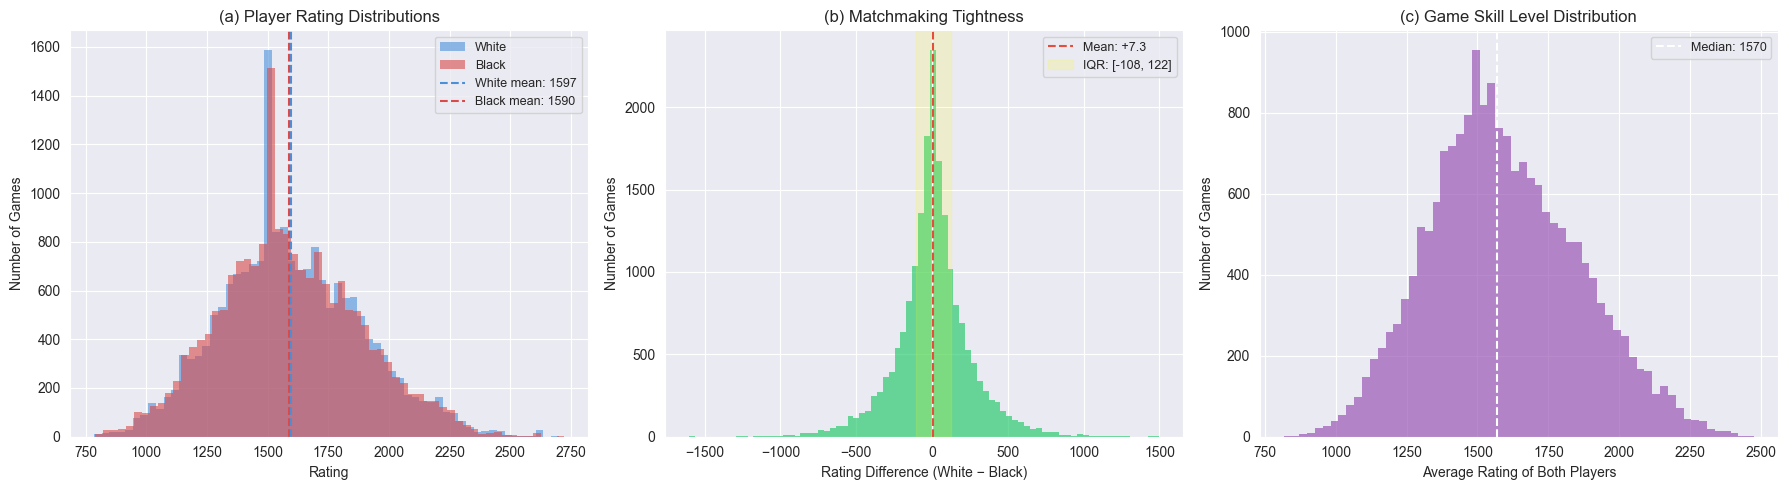

In [55]:
# Figure 1: Lichess rating distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3 subplots side by side

# Panel A: White & Black rating distributions overlaid
axes[0].hist(lichess['white_rating'], bins=60, alpha=0.6,
             color='#4a90d9', label='White', edgecolor='none')
axes[0].hist(lichess['black_rating'], bins=60, alpha=0.6,
             color='#d94a4a', label='Black', edgecolor='none')
axes[0].axvline(lichess['white_rating'].mean(), color='#4a90d9',
               linestyle='--', linewidth=1.5, label=f'White mean: {lichess["white_rating"].mean():.0f}')
axes[0].axvline(lichess['black_rating'].mean(), color='#d94a4a',
               linestyle='--', linewidth=1.5, label=f'Black mean: {lichess["black_rating"].mean():.0f}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('(a) Player Rating Distributions')
axes[0].legend(fontsize=9)

# Panel B: Rating difference (white - black)
axes[1].hist(lichess['rating_diff'], bins=80, color='#2ecc71',
             edgecolor='none', alpha=0.7)
axes[1].axvline(0, color='white', linestyle='-', linewidth=1)
axes[1].axvline(lichess['rating_diff'].mean(), color='#e74c3c',
               linestyle='--', linewidth=1.5,
               label=f'Mean: {lichess["rating_diff"].mean():+.1f}')
# Shade the IQR (interquartile range)
q25 = lichess['rating_diff'].quantile(0.25)
q75 = lichess['rating_diff'].quantile(0.75)
axes[1].axvspan(q25, q75, alpha=0.15, color='yellow',
               label=f'IQR: [{q25:.0f}, {q75:.0f}]')
axes[1].set_xlabel('Rating Difference (White − Black)')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('(b) Matchmaking Tightness')
axes[1].legend(fontsize=9)

# Panel C: Average game rating (skill level of each game)
axes[2].hist(lichess['avg_rating'], bins=60, color='#9b59b6',
             edgecolor='none', alpha=0.7)
axes[2].axvline(lichess['avg_rating'].median(), color='white',
               linestyle='--', linewidth=1.5,
               label=f'Median: {lichess["avg_rating"].median():.0f}')
axes[2].set_xlabel('Average Rating of Both Players')
axes[2].set_ylabel('Number of Games')
axes[2].set_title('(c) Game Skill Level Distribution')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

The distributions tell a clear story. Both white and black ratings are approximately bell-shaped with a right skew most games cluster in the 1200–1800 range, with a long tail stretching toward 2700. The means are nearly identical (white 1597, black 1590), which is expected since matchmaking pairs players of similar strength.

Panel (b) is more revealing. The rating difference is tightly centered around zero with a mean of just +7.3 Lichess matchmaking is doing its job. The IQR spans roughly [-108, +122], meaning in 50% of games the players are within ~115 Elo of each other. This matters: tight matchmaking means the Elo formula is being tested in its most sensitive region, where predicted win probabilities sit close to 50%. That's where prediction is hardest and where model quality actually shows.

Panel (c) confirms that the bulk of games happen at the intermediate level (median 1570), with relatively few games above 2200 or below 1000.

To quantify how "normal" these distributions actually are:

In [56]:
# Normality diagnostics
for name, data in [('White rating', lichess['white_rating']),
                   ('Black Rating', lichess['black_rating']),
                   ('Rating Diff', lichess['rating_diff']),
                   ('Avg Rating', lichess['avg_rating'])]:
    sk = skew(data)
    ku = kurtosis(data)
    sample = data.sample(min(5000, len(data)), random_state=42)
    stat, p = shapiro(sample)  # W-statistic and p-value
    print(f'{name:15s}  skew={sk:+.3f}  kurtosis={ku:+.3f}  '
          f'Shapiro W={stat:.4f}  p={p:.2e}')


White rating     skew=+0.291  kurtosis=+0.021  Shapiro W=0.9952  p=7.29e-12
Black Rating     skew=+0.250  kurtosis=-0.057  Shapiro W=0.9949  p=2.85e-12
Rating Diff      skew=+0.072  kurtosis=+2.937  Shapiro W=0.9544  p=6.31e-37
Avg Rating       skew=+0.262  kurtosis=-0.242  Shapiro W=0.9942  p=2.43e-13


The skewness values are small and positive (~0.25–0.29 for individual ratings), confirming the mild rightward lean visible in the histograms. Rating difference is nearly symmetric (skew = +0.07) but has notable excess kurtosis (+2.94) — the distribution is sharply peaked with heavier tails than a normal. This makes sense: matchmaking concentrates most games near zero difference, but occasionally produces large mismatches (±500+) that inflate the tails.

Shapiro-Wilk rejects normality for all four distributions (p < 0.001), but with 19,000+ observations that's expected — the test picks up even trivial departures at this sample size. The W-statistics are all above 0.95, which in practical terms means "close to normal but not textbook perfect."

The takeaway: Elo's logistic model assumes normally distributed performance, not perfectly normal ratings. These distributions are close enough for the model to work — but the heavy tails in rating difference suggest there will be some extreme games where Elo's predictions are overconfident. I'll revisit this when I plot predicted vs actual win rates in Section 4.3.

Next question: does it matter which color you play?

### 4.2 Does White Really Have an Advantage?

Chess players take it as gospel that white has an edge the first move sets the tempo. But how big is this advantage in practice, and does it change depending on how strong the players are? Elo treats both colors identically: the formula only cares about the rating difference, not who plays white. If white's advantage is large or varies by skill level, that's a systematic bias the model ignores.

In [57]:
# Overall outcome breakdown by color
outcome_counts = lichess['winner'].value_counts()
total = len(lichess)
print(f'Overall Outcomes')
for outcome in ['white', 'black', 'draw']:
    n = outcome_counts[outcome]
    pct = n / total * 100
    print(f' {outcome:6s} {n:>6,} games ({pct:.1f}%)')
print(f'\nWhite advantage: {outcome_counts["white"] / total * 100:.1f}% vs '
      f'{outcome_counts["black"] / total * 100:.1f}%  '
      f'(+{(outcome_counts["white"] - outcome_counts["black"]) / total * 100:.1f} pp)')  # percentage points



Overall Outcomes
 white   9,545 games (49.9%)
 black   8,680 games (45.4%)
 draw      888 games (4.6%)

White advantage: 49.9% vs 45.4%  (+4.5 pp)


White wins 4.5 percentage points more often than black a meaningful edge. But the draw rate is only 4.6%, which is extremely low compared to professional over-the-board chess (where draws can exceed 50%). This is typical for online blitz/rapid: players fight to the finish rather than agree to draws.
A note on framing: the 4.5pp figure above is the raw gap between white's and black's win rates. Another way to measure the same thing is white's mean score above 50%, where draws count as half a win. I'll use this version later when testing significance, since it's the natural input to a one-proportion z-test.

The next question is whether this advantage is constant across skill levels, or whether stronger players experience it differently:

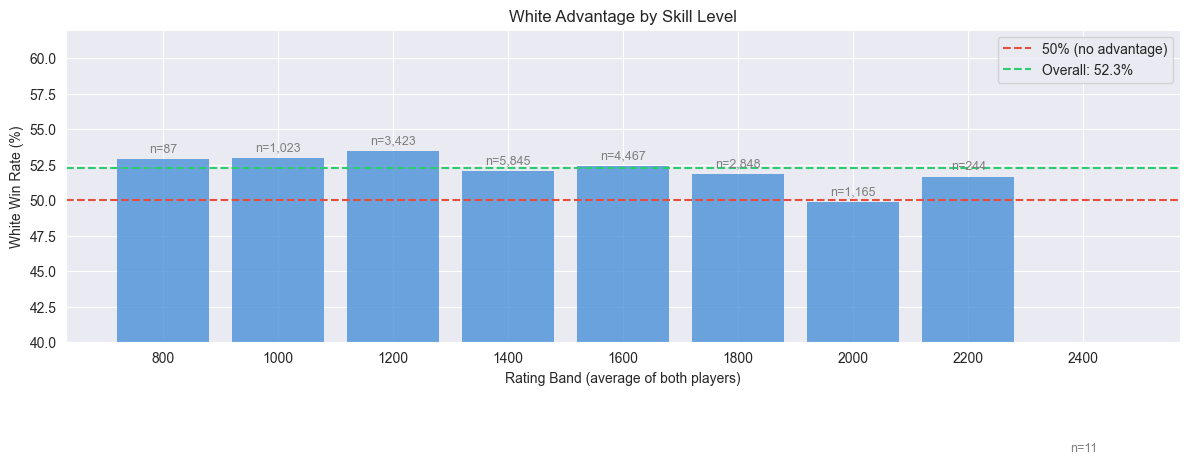


Exact values:
   800–1000: 52.9%  (n=87)
  1000–1200: 53.0%  (n=1,023)
  1200–1400: 53.5%  (n=3,423)
  1400–1600: 52.0%  (n=5,845)
  1600–1800: 52.4%  (n=4,467)
  1800–2000: 51.9%  (n=2,848)
  2000–2200: 49.9%  (n=1,165)
  2200–2400: 51.6%  (n=244)
  2400–2600: 31.8%  (n=11)


In [58]:
# White win rate grouped by rating band
band_stats = lichess.groupby('rating_band').agg(
    games=('white_score', 'size'),
    white_winrate=('white_score', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(band_stats['rating_band'].astype(str),
              band_stats['white_winrate'] * 100,
              color='#4a90d9', edgecolor='none', alpha=0.8)

# Reference lines
ax.axhline(50, color='#e74c3c', linestyle='--', linewidth=1.5,
           label='50% (no advantage)')
ax.axhline(lichess['white_score'].mean() * 100,
           color='#2ecc71', linestyle='--', linewidth=1.5,
           label=f'Overall: {lichess["white_score"].mean() * 100:.1f}%')

# Game counts above each bar
for bar, n in zip(bars, band_stats['games']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={n:,}', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Rating Band (average of both players)')
ax.set_ylabel('White Win Rate (%)')
ax.set_title('White Advantage by Skill Level')
ax.set_ylim(40, 62)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Exact values per band
print('\nExact values:')
for _, row in band_stats.iterrows():
    print(f'  {int(row["rating_band"]):>4d}–{int(row["rating_band"])+200}: '
          f'{row["white_winrate"]*100:.1f}%  (n={int(row["games"]):,})')

White's advantage is remarkably stable across most skill levels, hovering between 52-53% from beginner (800) all the way up to expert 2000.The pattern gets noisier at the top: 2000-2200 drops to 49.99%, 2200-2400 bounces back to 51.6%, and 2400-2600 shows 31.8% but that last band has only 11 games, fat too few to draw any conclusion.

The key insight for modeling: white's edge is real (~2–3 percentage points above 50%) and roughly constant across the rating spectrum. Elo ignores color entirely it predicts the same win probability regardless of who plays white. This means Elo will systematically underestimate white's chances and overestimate black's by a small but consistent margin. A more sophisticated model could include a color correction term, but for now I'll treat this as a known limitation and quantify its impact when I evaluate calibration in Section 4.3.

Next: how well does the Elo formula actually predict outcomes?